In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(
    "../data/raw/gios_pm_measurements_1y.parquet"
)

# 1. Kształt danych

In [3]:
df.head()

,station_id,sensor_id,station_name,city,voivodeship,Parametr,Data,Wartość,Kod stanowiska
0,117,669,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,PM10,2025-08-20,29.9,DsWrocWybCon-PM10-24g
1,117,669,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,PM10,2025-08-21,23.0,DsWrocWybCon-PM10-24g
2,117,669,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,PM10,2025-08-22,21.2,DsWrocWybCon-PM10-24g
3,117,669,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,PM10,2025-08-23,23.5,DsWrocWybCon-PM10-24g
4,117,669,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,PM10,2025-08-24,10.2,DsWrocWybCon-PM10-24g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225014 entries, 0 to 225013
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   station_id      225014 non-null  int64         
 1   sensor_id       225014 non-null  int64         
 2   station_name    225014 non-null  object        
 3   city            225014 non-null  object        
 4   voivodeship     225014 non-null  object        
 5   Parametr        225014 non-null  object        
 6   Data            225014 non-null  datetime64[ns]
 7   Wartość         225014 non-null  float64       
 8   Kod stanowiska  225014 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 15.5+ MB


### Wnioski

Zbiór zawiera 225 014 rekordów i 9 kolumn.  
Nie występują braki typu `NaN` w istniejących rekordach.  
Kolumna `Data` ma poprawny typ `datetime64[ns]`, dzięki czemu dane są gotowe do analizy szeregów czasowych.

In [6]:
print("Od:", df["Data"].min())
print("Do:", df["Data"].max())

Od: 2025-08-20 00:00:00
Do: 2026-08-20 23:00:00


In [7]:
df["Parametr"].value_counts()

Parametr
PM10     113990
PM2.5    111024
Name: count, dtype: int64

In [11]:
df["station_id"].nunique()

16

In [9]:
df["sensor_id"].nunique()

43

In [12]:
stations = (
    df[
        [
            "station_id",
            "station_name",
            "city",
            "voivodeship",
        ]
    ]
    .drop_duplicates()
    .sort_values("voivodeship")
)

stations

,station_id,station_name,city,voivodeship
0,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE
8768,156,"Bydgoszcz, Pl. Poznański",Bydgoszcz,KUJAWSKO-POMORSKIE
24890,258,"Lublin, ul. Śliwińskiego",Lublin,LUBELSKIE
43479,361,Gorzów Wlkp. ul. Kosynierów Gdyńskich,Gorzów Wielkopolski,LUBUSKIE
78882,530,"Warszawa, Al. Niepodległości",Warszawa,MAZOWIECKIE
61353,400,"Kraków, Aleja Krasińskiego",Kraków,MAŁOPOLSKIE
93238,590,"Opole, Os. Armii Krajowej",Opole,OPOLSKIE
110034,671,"Rzeszów, Al. Rejtana",Rzeszów,PODKARPACKIE
93923,609,"Białystok, ul. Warszawska",Białystok,PODLASKIE
119279,729,"Gdańsk, ul. Powstańców Warszawskich",Gdańsk,POMORSKIE


In [13]:
df.isna().sum()

station_id        0
sensor_id         0
station_name      0
city              0
voivodeship       0
Parametr          0
Data              0
Wartość           0
Kod stanowiska    0
dtype: int64

### Brakujące wartości

W zbiorze nie występują wartości typu NaN.  
Oznacza to, że każdy istniejący rekord posiada komplet podstawowych informacji.

Braki mogą jednak występować jako całkowicie brakujące momenty czasowe,
dlatego konieczna jest osobna analiza luk w szeregu czasowym.

In [15]:
df = df.sort_values(
    ["sensor_id", "Data"]
).copy()

In [16]:
df["time_diff"] = (
    df.groupby("sensor_id")["Data"]
    .diff()
)

In [17]:
df["time_diff"].value_counts().head(10)

time_diff
0 days 01:00:00    218885
1 days 00:00:00      5573
0 days 02:00:00       252
0 days 03:00:00        62
2 days 00:00:00        23
0 days 05:00:00        22
0 days 04:00:00        20
0 days 10:00:00        14
0 days 06:00:00        13
0 days 07:00:00        11
Name: count, dtype: int64

In [18]:
sensor_frequency = (
    df.groupby("sensor_id")["time_diff"]
    .agg(
        lambda x: (
            x.mode().iloc[0]
            if not x.mode().empty
            else pd.NaT
        )
    )
)

In [19]:
sensor_frequency.value_counts()

time_diff
0 days 01:00:00    26
1 days 00:00:00    17
Name: count, dtype: int64

In [20]:
df["expected_diff"] = (
    df["sensor_id"].map(sensor_frequency)
)

In [21]:
df["is_gap"] = (
    df["time_diff"] > df["expected_diff"]
)

In [22]:
df["is_gap"].sum()

np.int64(515)

In [23]:
df["missing_measurements"] = (
    df["time_diff"] / df["expected_diff"] - 1
).clip(lower=0)

In [24]:
df["missing_measurements"].sum()

np.float64(4373.0)

In [25]:
gap_summary = (
    df.groupby(
        [
            "station_id",
            "station_name",
            "Parametr",
        ]
    )
    .agg(
        observed_measurements=("Wartość", "count"),
        missing_measurements=(
            "missing_measurements",
            "sum",
        ),
    )
    .reset_index()
)

In [26]:
gap_summary["expected_measurements"] = (
    gap_summary["observed_measurements"]
    + gap_summary["missing_measurements"]
)

In [27]:
gap_summary["missing_percent"] = (
    gap_summary["missing_measurements"]
    / gap_summary["expected_measurements"]
    * 100
)

In [28]:
gap_summary.sort_values(
    "missing_percent",
    ascending=False,
)

,station_id,station_name,Parametr,observed_measurements,missing_measurements,expected_measurements,missing_percent
3,156,"Bydgoszcz, Pl. Poznański",PM2.5,7557,1227.0,8784.0,13.968579
28,986,"Szczecin, ul. Andrzejewskiego",PM10,8603,527.0,9130.0,5.772180
29,986,"Szczecin, ul. Andrzejewskiego",PM2.5,8604,526.0,9130.0,5.761227
0,117,"Wrocław, wyb. Conrada-Korzeniowskiego",PM10,301,14.0,315.0,4.444444
19,671,"Rzeszów, Al. Rejtana",PM2.5,328,13.0,341.0,3.812317
1,117,"Wrocław, wyb. Conrada-Korzeniowskiego",PM2.5,8467,317.0,8784.0,3.608834
30,11195,"Kielce, ul. Targowa",PM10,8893,237.0,9130.0,2.595838
2,156,"Bydgoszcz, Pl. Poznański",PM10,8565,219.0,8784.0,2.493169
31,11195,"Kielce, ul. Targowa",PM2.5,8577,207.0,8784.0,2.356557
18,671,"Rzeszów, Al. Rejtana",PM10,8917,208.0,9125.0,2.279452


In [29]:
sensor_ranges = (
    df.groupby(
        [
            "station_id",
            "station_name",
            "sensor_id",
            "Parametr",
        ]
    )
    .agg(
        first_measurement=("Data", "min"),
        last_measurement=("Data", "max"),
        measurements=("Data", "count"),
    )
    .reset_index()
)

In [30]:
sensor_ranges["frequency"] = (
    sensor_ranges["sensor_id"].map(sensor_frequency)
)

In [31]:
sensor_ranges.sort_values(
    ["station_name", "Parametr"]
)

,station_id,station_name,sensor_id,Parametr,first_measurement,last_measurement,measurements,frequency
18,609,"Białystok, ul. Warszawska",4024,PM10,2025-08-20 00:00:00,2026-08-20 23:00:00,8683,0 days 01:00:00
19,609,"Białystok, ul. Warszawska",4025,PM2.5,2025-08-20 00:00:00,2026-06-02 00:00:00,281,1 days 00:00:00
20,609,"Białystok, ul. Warszawska",32441,PM2.5,2025-10-24 13:00:00,2026-08-20 23:00:00,7147,0 days 01:00:00
2,156,"Bydgoszcz, Pl. Poznański",965,PM10,2025-08-20 00:00:00,2026-08-20 23:00:00,8565,0 days 01:00:00
3,156,"Bydgoszcz, Pl. Poznański",966,PM2.5,2025-08-20 00:00:00,2026-08-20 23:00:00,7557,0 days 01:00:00
30,861,"Elbląg, ul. Bażyńskiego",5683,PM10,2025-08-20 00:00:00,2026-08-20 23:00:00,8618,0 days 01:00:00
31,861,"Elbląg, ul. Bażyńskiego",5684,PM10,2025-08-20 00:00:00,2026-07-27 00:00:00,338,1 days 00:00:00
32,861,"Elbląg, ul. Bażyńskiego",5685,PM2.5,2025-08-20 00:00:00,2026-08-10 00:00:00,354,1 days 00:00:00
33,861,"Elbląg, ul. Bażyńskiego",20691,PM2.5,2025-08-20 00:00:00,2026-08-20 23:00:00,8618,0 days 01:00:00
24,729,"Gdańsk, ul. Powstańców Warszawskich",4681,PM10,2025-08-20 00:00:00,2026-08-20 23:00:00,8711,0 days 01:00:00


### Analiza częstotliwości i luk czasowych

W zbiorze znajduje się 43 sensory. Dla 26 sensorów dominującą
częstotliwością pomiarów jest 1 godzina, natomiast dla 17 sensorów
1 doba.

Wykryto 515 przerw dłuższych niż typowa częstotliwość danego sensora.
Przerwy te odpowiadają łącznie 4373 brakującym pomiarom wewnątrz
obserwowanych szeregów czasowych.

Samo występowanie przerwy nie oznacza wartości równej zero – brakujący
pomiar oznacza brak obserwacji.

W dalszej analizie pokrycia należy dodatkowo uwzględnić początek
i koniec dostępności każdego sensora względem pełnego analizowanego
zakresu dat.

In [32]:
pm10 = df[
    df["Parametr"] == "PM10"
]["Wartość"].dropna()

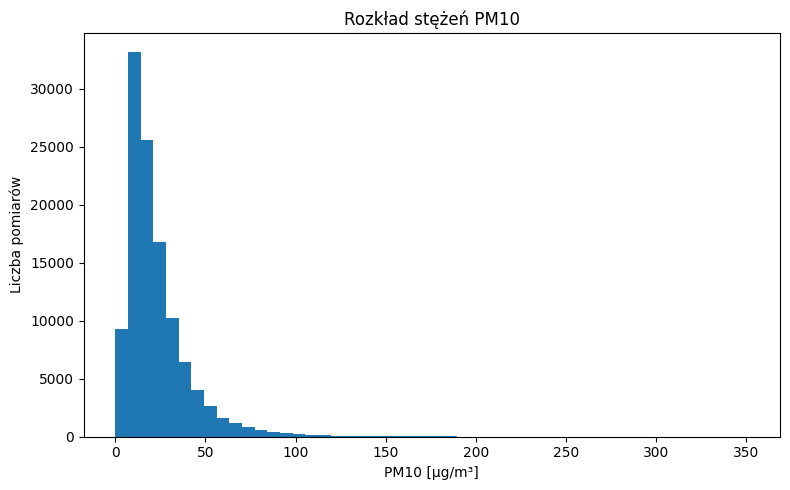

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(
    pm10,
    bins=50,
)

plt.xlabel("PM10 [µg/m³]")
plt.ylabel("Liczba pomiarów")
plt.title("Rozkład stężeń PM10")

plt.tight_layout()
plt.show()

In [34]:
pm25 = df[
    df["Parametr"] == "PM2.5"
]["Wartość"].dropna()

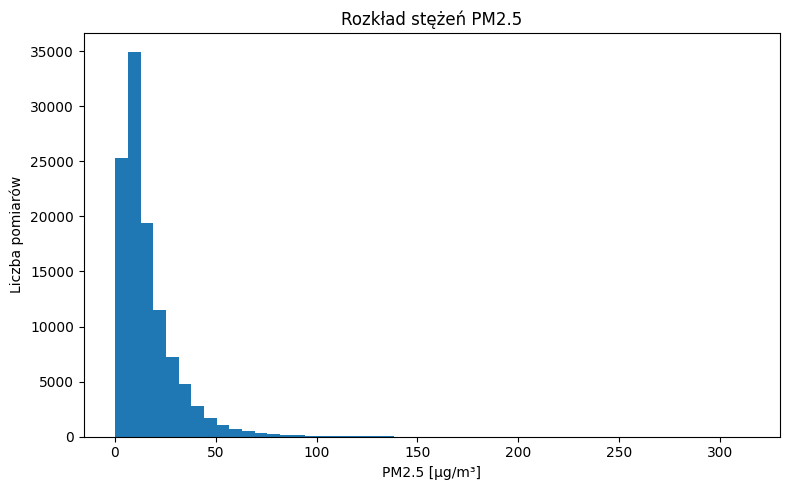

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    pm25,
    bins=50,
)

plt.xlabel("PM2.5 [µg/m³]")
plt.ylabel("Liczba pomiarów")
plt.title("Rozkład stężeń PM2.5")

plt.tight_layout()
plt.show()

In [36]:
df.groupby("Parametr")["Wartość"].describe()

,count,mean,std,min,25%,50%,75%,max
Parametr,,,,,,,,
PM10,113990.0,22.944746,19.00231,0.0,11.1,17.7,28.5,351.3
PM2.5,111024.0,16.156277,14.76704,0.2,6.8,11.6,20.7,314.1


### Wnioski z rozkładów PM

Dla obu parametrów średnia jest wyższa od mediany, co wskazuje
na prawostronną skośność rozkładu.

PM10 osiąga wyższe wartości przeciętne niż PM2.5.
W zbiorze występują również wysokie wartości maksymalne,
jednak nie są one automatycznie traktowane jako błędne obserwacje,
ponieważ mogą odpowiadać rzeczywistym epizodom smogowym,
szczególnie w sezonie zimowym.

In [37]:
katowice_pm10 = df[
    (df["city"] == "Katowice")
    & (df["Parametr"] == "PM10")
].copy()

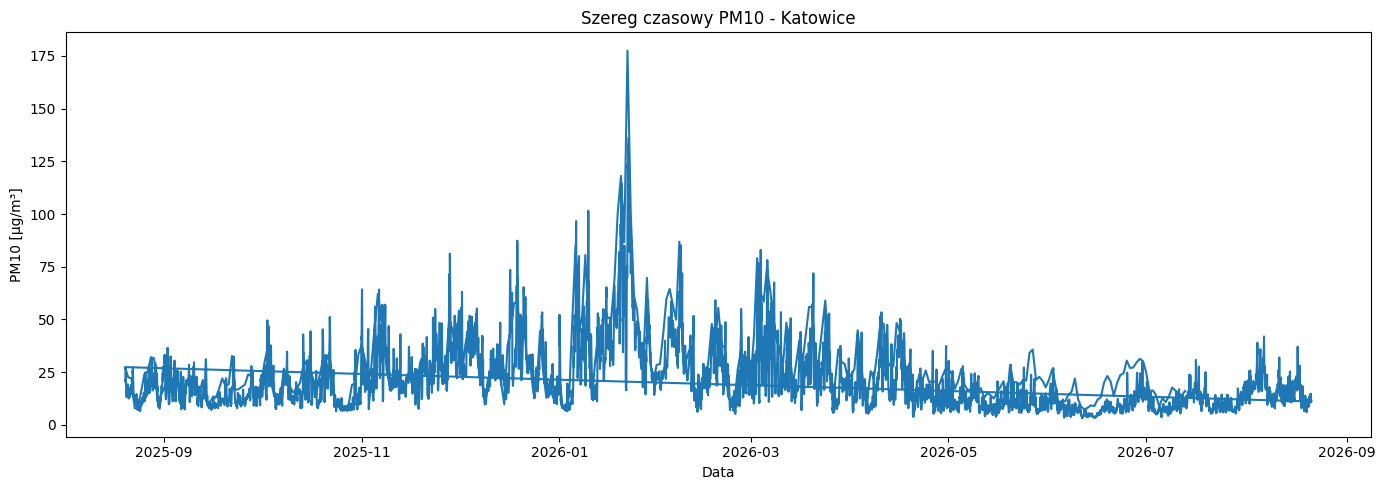

In [38]:
plt.figure(figsize=(14, 5))

plt.plot(
    katowice_pm10["Data"],
    katowice_pm10["Wartość"],
)

plt.xlabel("Data")
plt.ylabel("PM10 [µg/m³]")
plt.title("Szereg czasowy PM10 - Katowice")

plt.tight_layout()
plt.show()

In [39]:
katowice_pm25 = df[
    (df["city"] == "Katowice")
    & (df["Parametr"] == "PM2.5")
].copy()

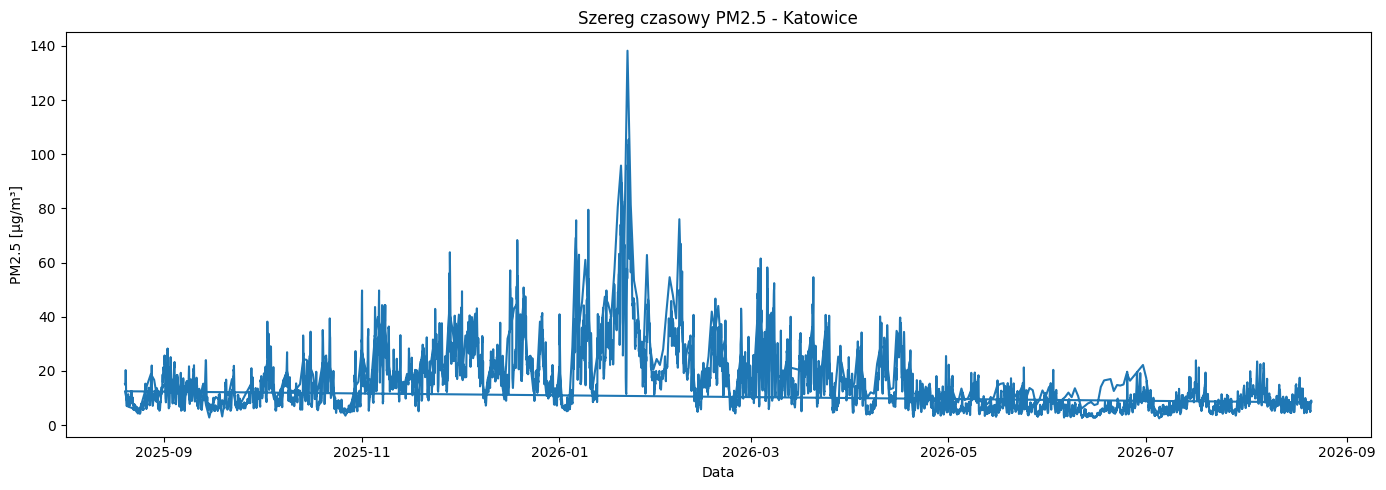

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    katowice_pm25["Data"],
    katowice_pm25["Wartość"],
)

plt.xlabel("Data")
plt.ylabel("PM2.5 [µg/m³]")
plt.title("Szereg czasowy PM2.5 - Katowice")

plt.tight_layout()
plt.show()

### Wnioski z analizy szeregów czasowych

Dla PM10 i PM2.5 widoczna jest wyraźna sezonowość.
Najwyższe wartości pojawiają się głównie w okresie zimowym,
natomiast w miesiącach letnich stężenia są niższe i bardziej stabilne.

Zaobserwowane wysokie zimowe piki nie są automatycznie traktowane
jako błędy lub wartości odstające, ponieważ mogą odpowiadać
rzeczywistym epizodom smogowym.

### raport pokrycia + wstepny wybor stacji do modelu

In [43]:
analysis_start = pd.Timestamp("2025-08-20 00:00")
analysis_end = pd.Timestamp("2026-08-20 23:00")

In [44]:
sensor_ranges["expected_full_period"] = (
    (analysis_end - analysis_start)
    / sensor_ranges["frequency"]
    + 1
)

In [45]:
sensor_ranges["coverage_percent"] = (
    sensor_ranges["measurements"]
    / sensor_ranges["expected_full_period"]
    * 100
)

In [46]:
sensor_ranges["missing_percent_full_period"] = (
    100 - sensor_ranges["coverage_percent"]
)

In [47]:
sensor_ranges.sort_values(
    "coverage_percent"
).head(15)

,station_id,station_name,sensor_id,Parametr,first_measurement,last_measurement,measurements,frequency,expected_full_period,coverage_percent,missing_percent_full_period
19,609,"Białystok, ul. Warszawska",4025,PM2.5,2025-08-20 00:00:00,2026-06-02 00:00:00,281,1 days 00:00:00,366.958333,76.575451,23.424549
20,609,"Białystok, ul. Warszawska",32441,PM2.5,2025-10-24 13:00:00,2026-08-20 23:00:00,7147,0 days 01:00:00,8784.000000,81.363843,18.636157
15,530,"Warszawa, Al. Niepodległości",3585,PM2.5,2025-08-20 00:00:00,2026-06-15 07:00:00,7178,0 days 01:00:00,8784.000000,81.716758,18.283242
14,530,"Warszawa, Al. Niepodległości",3584,PM10,2025-08-20 00:00:00,2026-06-15 07:00:00,7178,0 days 01:00:00,8784.000000,81.716758,18.283242
0,117,"Wrocław, wyb. Conrada-Korzeniowskiego",669,PM10,2025-08-20 00:00:00,2026-06-30 00:00:00,301,1 days 00:00:00,366.958333,82.025661,17.974339
29,814,"Katowice, ul. Kossutha",5379,PM2.5,2025-08-20 00:00:00,2026-07-13 00:00:00,314,1 days 00:00:00,366.958333,85.568298,14.431702
3,156,"Bydgoszcz, Pl. Poznański",966,PM2.5,2025-08-20 00:00:00,2026-08-20 23:00:00,7557,0 days 01:00:00,8784.000000,86.031421,13.968579
41,11195,"Kielce, ul. Targowa",19752,PM10,2025-08-20 00:00:00,2026-07-31 00:00:00,316,1 days 00:00:00,366.958333,86.113319,13.886681
21,671,"Rzeszów, Al. Rejtana",4387,PM10,2025-08-20 00:00:00,2026-07-26 00:00:00,318,1 days 00:00:00,366.958333,86.658340,13.341660
27,814,"Katowice, ul. Kossutha",5377,PM10,2025-08-20 00:00:00,2026-07-13 00:00:00,326,1 days 00:00:00,366.958333,88.838424,11.161576


In [48]:
sensor_ranges.sort_values(
    "coverage_percent",
    ascending=False
).head(15)

,station_id,station_name,sensor_id,Parametr,first_measurement,last_measurement,measurements,frequency,expected_full_period,coverage_percent,missing_percent_full_period
7,295,"Łódź, ul. Czernika",2071,PM2.5,2025-08-20,2026-08-20 23:00:00,8775,0 days 01:00:00,8784.0,99.897541,0.102459
28,814,"Katowice, ul. Kossutha",5378,PM2.5,2025-08-20,2026-08-20 23:00:00,8769,0 days 01:00:00,8784.0,99.829235,0.170765
26,814,"Katowice, ul. Kossutha",5376,PM10,2025-08-20,2026-08-20 23:00:00,8769,0 days 01:00:00,8784.0,99.829235,0.170765
9,361,Gorzów Wlkp. ul. Kosynierów Gdyńskich,2421,PM10,2025-08-20,2026-08-20 23:00:00,8767,0 days 01:00:00,8784.0,99.806466,0.193534
11,361,Gorzów Wlkp. ul. Kosynierów Gdyńskich,26165,PM2.5,2025-08-20,2026-08-20 23:00:00,8767,0 days 01:00:00,8784.0,99.806466,0.193534
13,400,"Kraków, Aleja Krasińskiego",2752,PM2.5,2025-08-20,2026-08-20 23:00:00,8766,0 days 01:00:00,8784.0,99.795082,0.204918
34,944,"Poznań, ul. Dąbrowskiego",6085,PM10,2025-08-20,2026-08-20 23:00:00,8765,0 days 01:00:00,8784.0,99.783698,0.216302
35,944,"Poznań, ul. Dąbrowskiego",20176,PM2.5,2025-08-20,2026-08-20 23:00:00,8765,0 days 01:00:00,8784.0,99.783698,0.216302
6,295,"Łódź, ul. Czernika",2069,PM10,2025-08-20,2026-08-20 23:00:00,8765,0 days 01:00:00,8784.0,99.783698,0.216302
12,400,"Kraków, Aleja Krasińskiego",2750,PM10,2025-08-20,2026-08-20 23:00:00,8763,0 days 01:00:00,8784.0,99.760929,0.239071


In [49]:
coverage_report = sensor_ranges[
    [
        "station_id",
        "station_name",
        "sensor_id",
        "Parametr",
        "frequency",
        "first_measurement",
        "last_measurement",
        "measurements",
        "expected_full_period",
        "coverage_percent",
        "missing_percent_full_period",
    ]
].copy()

In [50]:
coverage_report.to_csv(
    "../data/processed/gios_coverage_report.csv",
    index=False,
)

### Wstępny wybór stacji do modelu

Na podstawie raportu pokrycia stwierdzono, że 12 z 16 analizowanych stacji
posiada godzinowe pomiary zarówno PM10, jak i PM2.5.

Najwyższe pokrycie danych występuje m.in. dla stacji w Łodzi, Gorzowie
Wielkopolskim, Krakowie, Gdańsku, Katowicach, Elblągu i Poznaniu,
gdzie dostępność danych dla obu parametrów przekracza około 98–99%.

Stacje we Wrocławiu, Lublinie, Opolu i Rzeszowie nie posiadają
godzinowych danych dla obu analizowanych parametrów, dlatego są
mniej odpowiednie do modelu opartego na danych godzinowych.

Ostateczny wybór stacji zostanie wykonany po połączeniu danych
o jakości powietrza z danymi pogodowymi i sprawdzeniu wspólnego
pokrycia czasowego.

# 2. Statystyka

## 2.1. Sezonowość PM

In [51]:
df["month"] = df["Data"].dt.month

In [52]:
monthly_pm = (
    df.groupby(["month", "Parametr"])["Wartość"]
    .mean()
    .reset_index()
)

monthly_pm

,month,Parametr,Wartość
0,1,PM10,41.068397
1,1,PM2.5,34.223604
2,2,PM10,31.246595
3,2,PM2.5,24.801593
4,3,PM10,38.121864
5,3,PM2.5,23.814397
6,4,PM10,21.331888
7,4,PM2.5,12.191206
8,5,PM10,17.439953
9,5,PM2.5,9.324606


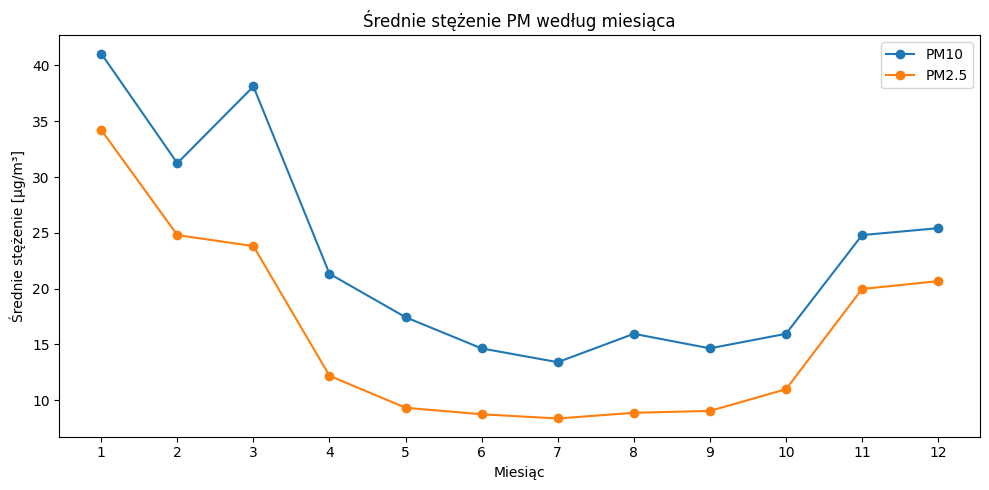

In [54]:
plt.figure(figsize=(10, 5))

for parameter in ["PM10", "PM2.5"]:
    data = monthly_pm[
        monthly_pm["Parametr"] == parameter
    ]

    plt.plot(
        data["month"],
        data["Wartość"],
        marker="o",
        label=parameter,
    )

plt.xlabel("Miesiąc")
plt.ylabel("Średnie stężenie [µg/m³]")
plt.title("Średnie stężenie PM według miesiąca")
plt.xticks(range(1, 13))
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
def get_season(month):
    if month in [10, 11, 12, 1, 2, 3]:
        return "heating"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "transition"

In [56]:
df["season"] = df["month"].apply(get_season)

In [57]:
season_pm = (
    df.groupby(["season", "Parametr"])["Wartość"]
    .mean()
    .reset_index()
)

season_pm

,season,Parametr,Wartość
0,heating,PM10,29.452125
1,heating,PM2.5,22.522236
2,summer,PM10,14.689746
3,summer,PM2.5,8.667948
4,transition,PM10,17.803831
5,transition,PM2.5,10.218819


### Wnioski z analizy sezonowości

Średnie stężenia PM10 i PM2.5 są wyraźnie wyższe w sezonie grzewczym
niż w okresie letnim.

Dla PM10 średnia w sezonie grzewczym wynosi około 29.45 µg/m³,
natomiast latem około 14.69 µg/m³.

Dla PM2.5 średnia w sezonie grzewczym wynosi około 22.52 µg/m³,
a latem około 8.67 µg/m³.

Wyniki wskazują na silną sezonowość stężeń pyłów zawieszonych,
z najwyższymi wartościami w miesiącach zimowych.

## 2.2. Dzień roboczy vs weekend

In [60]:
df["day_of_week"] = df["Data"].dt.dayofweek

In [61]:
df["is_weekend"] = df["day_of_week"] >= 5

In [62]:
df[["Data", "day_of_week", "is_weekend"]].head()

,Data,day_of_week,is_weekend
0,2025-08-20,2,False
1,2025-08-21,3,False
2,2025-08-22,4,False
3,2025-08-23,5,True
4,2025-08-24,6,True


In [64]:
weekday_weekend_summary = (
    df.groupby(["Parametr", "is_weekend"])["Wartość"]
    .agg(["count", "mean", "median", "std"])
)

weekday_weekend_summary

count       mean  median        std
Parametr is_weekend                                     
PM10     False       81602  23.769812    18.1  19.834268
         True        32388  20.865981    16.6  16.542505
PM2.5    False       79487  16.553434    11.8  15.460728
         True        31537  15.155268    11.4  12.799282

In [92]:
print(
    "PM10 różnica średnich:",
    pm10_weekend_mean - pm10_weekday_mean,
)

print(
    "PM2.5 różnica średnich:",
    pm25_weekend_mean - pm25_weekday_mean,
)

PM10 różnica średnich: -2.903830786796245
PM2.5 różnica średnich: -1.3981654799729704


In [68]:
from scipy.stats import mannwhitneyu

In [69]:
pm10_weekday = df[
    (df["Parametr"] == "PM10")
    & (~df["is_weekend"])
]["Wartość"].dropna()

pm10_weekend = df[
    (df["Parametr"] == "PM10")
    & (df["is_weekend"])
]["Wartość"].dropna()

In [70]:
u_stat_pm10, p_value_pm10 = mannwhitneyu(
    pm10_weekday,
    pm10_weekend,
    alternative="two-sided",
)

print("PM10")
print("U =", u_stat_pm10)
print("p-value =", p_value_pm10)

PM10
U = 1433393759.5
p-value = 1.5422359421769247e-110


In [71]:
pm25_weekday = df[
    (df["Parametr"] == "PM2.5")
    & (~df["is_weekend"])
]["Wartość"].dropna()

pm25_weekend = df[
    (df["Parametr"] == "PM2.5")
    & (df["is_weekend"])
]["Wartość"].dropna()

In [72]:
u_stat_pm25, p_value_pm25 = mannwhitneyu(
    pm25_weekday,
    pm25_weekend,
    alternative="two-sided",
)

print("PM2.5")
print("U =", u_stat_pm25)
print("p-value =", p_value_pm25)

PM2.5
U = 1291366372.0
p-value = 3.1323405706603813e-15


### Dzień roboczy a weekend

Średnie stężenie PM10 wyniosło 23.77 µg/m³ w dni robocze
oraz 20.87 µg/m³ w weekendy. Różnica średnich wyniosła
około 2.90 µg/m³.

Dla PM2.5 średnie wartości wyniosły odpowiednio 16.55 µg/m³
i 15.16 µg/m³, co daje różnicę około 1.40 µg/m³.

Do porównania rozkładów zastosowano nieparametryczny test
Manna–Whitneya. Otrzymano p = 1.54 × 10⁻¹¹⁰ dla PM10
oraz p = 3.13 × 10⁻¹⁵ dla PM2.5.

### Interpretacja testu Manna–Whitneya

Dla PM10 otrzymano p-value = 1,54 × 10⁻¹¹⁰, a dla PM2.5
p-value = 3,13 × 10⁻¹⁵. Obie wartości są znacznie mniejsze
od przyjętego poziomu istotności α = 0,05.

Oznacza to, że istnieją statystycznie istotne różnice między
rozkładami stężeń PM w dni robocze i w weekendy.

Średnie stężenie PM10 było w weekendy niższe o około 2,90 µg/m³,
a PM2.5 niższe o około 1,40 µg/m³ w porównaniu z dniami roboczymi.

Wyniki sugerują więc, że w analizowanym zbiorze stężenia pyłów
zawieszonych były niższe w weekendy niż w dni robocze.

## 2.3. Zależność PM od pogody

In [75]:
weather_df = pd.read_parquet(
    "../data/raw/open_meteo_weather_1y.parquet"
)

In [76]:
weather_df.head()

,station_id,station_name,city,voivodeship,latitude,longitude,timestamp_utc,temperature_2m,relative_humidity_2m,wind_speed_10m
0,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,51.129378,17.02925,2025-08-20 00:00:00+00:00,15.5,78,4.8
1,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,51.129378,17.02925,2025-08-20 01:00:00+00:00,13.8,86,5.0
2,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,51.129378,17.02925,2025-08-20 02:00:00+00:00,13.1,89,4.3
3,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,51.129378,17.02925,2025-08-20 03:00:00+00:00,12.6,91,3.2
4,117,"Wrocław, wyb. Conrada-Korzeniowskiego",Wrocław,DOLNOŚLĄSKIE,51.129378,17.02925,2025-08-20 04:00:00+00:00,12.4,92,2.3


In [80]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140544 entries, 0 to 140543
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   station_id            140544 non-null  int64              
 1   station_name          140544 non-null  object             
 2   city                  140544 non-null  object             
 3   voivodeship           140544 non-null  object             
 4   latitude              140544 non-null  float64            
 5   longitude             140544 non-null  float64            
 6   timestamp_utc         140544 non-null  datetime64[ns, UTC]
 7   temperature_2m        140544 non-null  float64            
 8   relative_humidity_2m  140544 non-null  int64              
 9   wind_speed_10m        140544 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(4), int64(2), object(3)
memory usage: 10.7+ MB


In [82]:
from datetime import timezone, timedelta

In [83]:
cet = timezone(timedelta(hours=1))

In [84]:
df["timestamp_local"] = (
    df["Data"]
    .dt.tz_localize(cet)
)

In [85]:
df["timestamp_utc"] = (
    df["timestamp_local"]
    .dt.tz_convert("UTC")
)

In [86]:
df[
    [
        "Data",
        "timestamp_local",
        "timestamp_utc",
    ]
].head()

,Data,timestamp_local,timestamp_utc
0,2025-08-20,2025-08-20 00:00:00+01:00,2025-08-19 23:00:00+00:00
1,2025-08-21,2025-08-21 00:00:00+01:00,2025-08-20 23:00:00+00:00
2,2025-08-22,2025-08-22 00:00:00+01:00,2025-08-21 23:00:00+00:00
3,2025-08-23,2025-08-23 00:00:00+01:00,2025-08-22 23:00:00+00:00
4,2025-08-24,2025-08-24 00:00:00+01:00,2025-08-23 23:00:00+00:00


In [87]:
merged_df = df.merge(
    weather_df,
    on=["station_id", "timestamp_utc"],
    how="left",
)

In [88]:
merged_df[
    [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
    ]
].isna().mean() * 100

temperature_2m          0.018666
relative_humidity_2m    0.018666
wind_speed_10m          0.018666
dtype: float64

### korelacje

In [89]:
pm10_corr = merged_df[
    merged_df["Parametr"] == "PM10"
][
    [
        "Wartość",
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
    ]
].corr()

pm10_corr

,Wartość,temperature_2m,relative_humidity_2m,wind_speed_10m
Wartość,1.000000,-0.355112,0.097355,-0.243251
temperature_2m,-0.355112,1.000000,-0.515184,-0.048082
relative_humidity_2m,0.097355,-0.515184,1.000000,-0.123940
wind_speed_10m,-0.243251,-0.048082,-0.123940,1.000000


In [90]:
pm25_corr = merged_df[
    merged_df["Parametr"] == "PM2.5"
][
    [
        "Wartość",
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
    ]
].corr()

pm25_corr

,Wartość,temperature_2m,relative_humidity_2m,wind_speed_10m
Wartość,1.000000,-0.481848,0.269363,-0.229257
temperature_2m,-0.481848,1.000000,-0.510720,-0.048432
relative_humidity_2m,0.269363,-0.510720,1.000000,-0.124951
wind_speed_10m,-0.229257,-0.048432,-0.124951,1.000000


In [91]:
merged_df["temperature_2m"].isna().sum()

np.int64(42)

### Korelacja PM z warunkami pogodowymi

Dla PM10 stwierdzono ujemną korelację z temperaturą
(r = -0,355) oraz z prędkością wiatru (r = -0,243).
Korelacja z wilgotnością była bardzo słaba i dodatnia
(r = 0,097).

Dla PM2.5 najsilniejszą zależność zaobserwowano dla temperatury
(r = -0,482). Korelacja z prędkością wiatru również była ujemna
(r = -0,229), natomiast z wilgotnością dodatnia
(r = 0,269).

Wyniki wskazują, że wyższa temperatura i silniejszy wiatr
są związane z niższymi stężeniami pyłów zawieszonych.
Zależność ta jest szczególnie widoczna dla temperatury i PM2.5.